# Notebook 25 — Plating Entry and Observability Feasibility Audit

## Goal

This notebook audits whether lithium plating（析锂）can be activated, extracted, and interpreted in the PyBaMM aging-bridge workflow.

The purpose is not yet to establish a full plating fingerprint. The purpose is to test model availability, variable observability, and protocol sensitivity before running a full mechanism-fingerprint branch.

## Scientific context

Previous mechanism branches established three reference fingerprints:

- SEI-only aging（SEI 单机制老化）: capacity-dominant, voltage-secondary, derivative-auxiliary.
- Contact / ohmic resistance growth（接触/欧姆阻抗增长）: Ri(t)-dominant, post-ohmic-relaxation-invariant, capacity-weak.
- LAM（Loss of Active Material，活性材料损失）: capacity- and voltage-shape-sensitive, DVA-informative.

Lithium plating（析锂）is expected to be more protocol-sensitive than these mechanisms. It may depend strongly on charge rate, temperature, SOC window, and reversibility assumptions.

## Study design

This notebook performs an entry-level plating feasibility audit using OKane2022 with plating enabled.

Candidate stress conditions:

- baseline no-plating control at 25 °C,
- plating-enabled 1C charge at 25 °C,
- plating-enabled 1C charge at 10 °C,
- plating-enabled 2C charge at 10 °C.

The diagnostic goal is to check whether plating-related variables become nonzero and whether the resulting observables are physically interpretable.

## Mechanism Fingerprint Registry v0.2

This notebook reuses the registry established in Notebook 23:

- `capacity_RPT`
- `Ri_0.05s`
- `Ri_0.1s`
- `Ri_1s`
- `Ri_10s`
- `Ri_recovery_0.1s`
- `Ri_recovery_1s`
- `tau_FG_eff`
- `t95`
- `t99`
- `tau_tail`
- `recovery_amplitude`
- `recovery_area`
- `C25_central_VQ`
- `GITT_finite_rest`
- `ICA_DVA_central`
- `endpoint_boundary`
- `best_fitting_targets`
- `rejection_flags`

## Interpretation boundary

This notebook is a plating entry audit, not a full plating-aging fingerprint.

A plating signal is not accepted merely because a variable is nonzero. It must be checked against:

- protocol sensitivity,
- reversibility assumptions,
- capacity / LLI-like loss,
- voltage-boundary behavior,
- possible numerical or option-induced artifacts.

If plating variables remain zero or unstable, the branch must be revised before any fingerprint classification.

In [1]:
# Cell 1 — Imports, paths, and environment check（导入依赖、路径与环境检查）

from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path("/Users/louislu/projects/pybamm-aging-bridge")
DATA = REPO / "data"
FIGURES = REPO / "figures"
DOC_FIGURES = REPO / "docs" / "figures"
DOC_TABLES = REPO / "docs" / "tables"

for p in [DATA, FIGURES, DOC_FIGURES, DOC_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

print("[ENV] PyBaMM:", pybamm.__version__)
print("[ENV] Repository:", REPO)
print("[ENV] Data dir:", DATA)
print("[ENV] Figures dir:", FIGURES)

assert pybamm.__version__ == "26.3.1", "Expected PyBaMM 26.3.1 for this project."
assert REPO.exists(), f"Repository path does not exist: {REPO}"

print("[OK] Environment check passed.")

[ENV] PyBaMM: 26.3.1
[ENV] Repository: /Users/louislu/projects/pybamm-aging-bridge
[ENV] Data dir: /Users/louislu/projects/pybamm-aging-bridge/data
[ENV] Figures dir: /Users/louislu/projects/pybamm-aging-bridge/figures
[OK] Environment check passed.


In [2]:
# Cell 2 — Registry v0.2 loading and plating branch contract（注册表读取与析锂分支合同）

registry_path = DATA / "mechanism_fingerprint_registry_v0_2.csv"

if registry_path.exists():
    fingerprint_registry_v02 = pd.read_csv(registry_path)
    print(f"[OK] loaded registry: {registry_path}")
else:
    raise FileNotFoundError(
        "Mechanism Fingerprint Registry v0.2 not found. "
        "Run Notebook 23 first or restore mechanism_fingerprint_registry_v0_2.csv."
    )

display(fingerprint_registry_v02)

PLATING_CONTRACT = pd.DataFrame([
    {
        "condition": "no_plating_25C_1C",
        "plating_mode": "none",
        "temperature_C": 25.0,
        "charge_rate": "1C",
        "initial_soc": 0.05,
        "role": "no-plating control",
    },
    {
        "condition": "plating_25C_1C",
        "plating_mode": "partially reversible",
        "temperature_C": 25.0,
        "charge_rate": "1C",
        "initial_soc": 0.05,
        "role": "temperature-normal plating-enabled control",
    },
    {
        "condition": "plating_10C_1C",
        "plating_mode": "partially reversible",
        "temperature_C": 10.0,
        "charge_rate": "1C",
        "initial_soc": 0.05,
        "role": "low-temperature plating stress",
    },
    {
        "condition": "plating_10C_2C",
        "plating_mode": "partially reversible",
        "temperature_C": 10.0,
        "charge_rate": "2C",
        "initial_soc": 0.05,
        "role": "low-temperature fast-charge plating stress",
    },
])

contract_path = DATA / "plating_entry_branch_contract.csv"
PLATING_CONTRACT.to_csv(contract_path, index=False)

print(f"[OK] saved: {contract_path}")
display(PLATING_CONTRACT)

[OK] loaded registry: /Users/louislu/projects/pybamm-aging-bridge/data/mechanism_fingerprint_registry_v0_2.csv


,metric_layer,description,primary_use,risk
0,capacity_RPT,External discharge capacity / capacity fade fr...,primary fitting target for capacity-loss mecha...,voltage cutoff can mix true capacity loss with...
1,Ri_0.05s,Pulse-on resistance at 50 ms,ohmic / very-fast polarization target,trigger and sampling-window sensitive
2,Ri_0.1s,Pulse-on resistance at 100 ms,ohmic / fast polarization target,still partly sensitive to pulse detection and ...
3,Ri_1s,Pulse-on resistance at 1 s,fast-to-medium polarization response,already includes non-ohmic transient contribution
4,Ri_10s,Pulse-on resistance near pulse end at 10 s,slow polarization / diffusion-sensitive resist...,strongly time-window dependent
5,Ri_recovery_0.1s,Pulse-off recovery resistance at 100 ms after ...,current-off ohmic / fast recovery descriptor,sensitive to pulse-off timing
6,Ri_recovery_1s,Pulse-off recovery resistance at 1 s after cur...,short recovery descriptor,mixes ohmic and early relaxation response
7,tau_FG_eff,Effective 63.2% voltage-recovery time after pu...,secondary relaxation descriptor,depends on U_inf and relaxation window
8,t95,Time to reach 95% of finite-window recovery am...,relaxation completion descriptor,sensitive to final-voltage definition
9,t99,Time to reach 99% of finite-window recovery am...,slow-tail recovery descriptor,sensitive to numerical floor and U_inf drift


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_branch_contract.csv


,condition,plating_mode,temperature_C,charge_rate,initial_soc,role
0,no_plating_25C_1C,none,25.0,1C,0.05,no-plating control
1,plating_25C_1C,partially reversible,25.0,1C,0.05,temperature-normal plating-enabled control
2,plating_10C_1C,partially reversible,10.0,1C,0.05,low-temperature plating stress
3,plating_10C_2C,partially reversible,10.0,2C,0.05,low-temperature fast-charge plating stress


## Methodological boundary before plating execution

Lithium plating（析锂）is protocol-sensitive.

This notebook must not infer a plating mechanism only from voltage changes. A valid plating entry signal requires direct plating-related variables or plating-linked capacity / lithium-loss indicators.

This notebook tests model availability and observability, not full mechanism uniqueness.

In [7]:
# Cell 3 — OKane2022 plating model builder with SEI background
# （带 SEI 背景的 OKane2022 析锂模型构建）

def build_plating_model(plating_mode="partially reversible", temperature_C=25.0):
    """
    Build OKane2022 DFN with lithium plating option.

    Important:
    OKane2022 partially reversible plating uses a dead-lithium decay relation
    that depends on SEI thickness. Therefore SEI must not be disabled.

    plating_mode:
        "none"
        "reversible"
        "partially reversible"
        "irreversible"
    """
    options = {
        "SEI": "solvent-diffusion limited",
        "SEI porosity change": "false",
        "lithium plating": plating_mode,
        "lithium plating porosity change": "false",
        "loss of active material": "none",
        "particle mechanics": "none",
        "thermal": "isothermal",
    }

    model = pybamm.lithium_ion.DFN(options=options)
    parameter_values = pybamm.ParameterValues("OKane2022")

    temperature_K = temperature_C + 273.15

    parameter_values.update(
        {
            "Ambient temperature [K]": temperature_K,
            "Initial temperature [K]": temperature_K,
        },
        check_already_exists=False,
    )

    return model, parameter_values


def make_solver():
    return pybamm.CasadiSolver(
        mode="safe",
        atol=1e-6,
        rtol=1e-6,
        dt_max=600,
    )


# Smoke test
for _, r in PLATING_CONTRACT.iterrows():
    try:
        model, pv = build_plating_model(
            plating_mode=r["plating_mode"],
            temperature_C=float(r["temperature_C"]),
        )
        print(
            f"[OK] model built: {r['condition']} | "
            f"SEI=solvent-diffusion limited | "
            f"plating={r['plating_mode']} | T={r['temperature_C']} °C"
        )
    except Exception as e:
        print(f"[FAIL] model build failed: {r['condition']} | {type(e).__name__}: {e}")
        raise

print("[OK] SEI-background plating model builder smoke test passed.")

[OK] model built: no_plating_25C_1C | SEI=solvent-diffusion limited | plating=none | T=25.0 °C
[OK] model built: plating_25C_1C | SEI=solvent-diffusion limited | plating=partially reversible | T=25.0 °C
[OK] model built: plating_10C_1C | SEI=solvent-diffusion limited | plating=partially reversible | T=10.0 °C
[OK] model built: plating_10C_2C | SEI=solvent-diffusion limited | plating=partially reversible | T=10.0 °C
[OK] SEI-background plating model builder smoke test passed.


In [8]:
# Cell 4 — Plating variable availability audit（析锂变量可用性审计）

def list_model_variables_containing(model, patterns):
    names = list(model.variables.keys())
    rows = []
    for name in names:
        lname = name.lower()
        if any(p.lower() in lname for p in patterns):
            rows.append({"variable": name})
    return pd.DataFrame(rows)


# Use plating-enabled model for variable audit
model_audit, pv_audit = build_plating_model(
    plating_mode="partially reversible",
    temperature_C=10.0,
)

plating_variable_inventory = list_model_variables_containing(
    model_audit,
    patterns=["plating", "lithium plating", "dead lithium", "lithium lost"],
)

inventory_path = DATA / "plating_entry_variable_inventory.csv"
plating_variable_inventory.to_csv(inventory_path, index=False)

print(f"[OK] saved: {inventory_path}")
display(plating_variable_inventory)

assert len(plating_variable_inventory) > 0, "No plating-related variables found."

print("[OK] Plating-related variable inventory available.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_variable_inventory.csv


,variable
0,Negative lithium plating concentration [mol.m-3]
1,X-averaged negative lithium plating concentrat...
2,Volume-averaged negative lithium plating conce...
3,Negative dead lithium concentration [mol.m-3]
4,X-averaged negative dead lithium concentration...
5,Volume-averaged negative dead lithium concentr...
6,Negative lithium plating thickness [m]
7,X-averaged negative lithium plating thickness [m]
8,Volume-averaged negative lithium plating thick...
9,Negative dead lithium thickness [m]


[OK] Plating-related variable inventory available.


In [9]:
# Cell 5 — Plating stress protocol builder（析锂应力协议构建）

def make_plating_stress_protocol(charge_rate="1C"):
    """
    Build charge-rest-discharge diagnostic protocol.

    The protocol starts at low SOC and applies fast charge to 4.2 V,
    then holds CV, rests, and runs a capacity-like discharge.
    """
    steps = [
        f"Charge at {charge_rate} until 4.2 V",
        "Hold at 4.2 V until C/20",
        "Rest for 60 minutes",
        "Discharge at C/3 until 2.5 V",
        "Rest for 60 minutes",
    ]
    return steps


PLATING_PERIOD = "10 seconds"

protocol_rows = []

for _, r in PLATING_CONTRACT.iterrows():
    steps = make_plating_stress_protocol(charge_rate=r["charge_rate"])
    protocol_rows.append({
        "condition": r["condition"],
        "plating_mode": r["plating_mode"],
        "temperature_C": r["temperature_C"],
        "charge_rate": r["charge_rate"],
        "initial_soc": r["initial_soc"],
        "period": PLATING_PERIOD,
        "n_steps": len(steps),
        "protocol": " | ".join(steps),
    })

plating_protocol_table = pd.DataFrame(protocol_rows)

protocol_path = DATA / "plating_entry_protocol_table.csv"
plating_protocol_table.to_csv(protocol_path, index=False)

print(f"[OK] saved: {protocol_path}")
display(plating_protocol_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_protocol_table.csv


,condition,plating_mode,temperature_C,charge_rate,initial_soc,period,n_steps,protocol
0,no_plating_25C_1C,none,25.0,1C,0.05,10 seconds,5,Charge at 1C until 4.2 V | Hold at 4.2 V until...
1,plating_25C_1C,partially reversible,25.0,1C,0.05,10 seconds,5,Charge at 1C until 4.2 V | Hold at 4.2 V until...
2,plating_10C_1C,partially reversible,10.0,1C,0.05,10 seconds,5,Charge at 1C until 4.2 V | Hold at 4.2 V until...
3,plating_10C_2C,partially reversible,10.0,2C,0.05,10 seconds,5,Charge at 2C until 4.2 V | Hold at 4.2 V until...


In [10]:
# Cell 6 — Run plating entry simulations（运行析锂入口仿真）

def run_plating_entry_condition(row):
    condition = row["condition"]
    plating_mode = row["plating_mode"]
    temperature_C = float(row["temperature_C"])
    charge_rate = row["charge_rate"]
    initial_soc = float(row["initial_soc"])

    model, pv = build_plating_model(
        plating_mode=plating_mode,
        temperature_C=temperature_C,
    )

    steps = make_plating_stress_protocol(charge_rate=charge_rate)
    experiment = pybamm.Experiment(steps, period=PLATING_PERIOD)

    sim = pybamm.Simulation(
        model,
        parameter_values=pv,
        experiment=experiment,
        solver=make_solver(),
    )

    print(
        f"[RUN] {condition} | plating={plating_mode} | "
        f"T={temperature_C} °C | charge={charge_rate}"
    )

    t0 = time.perf_counter()
    sol = sim.solve(initial_soc=initial_soc)
    elapsed = time.perf_counter() - t0

    print(f"[OK] solved: {condition} | runtime={elapsed:.1f} s")
    return sol


plating_solutions = {}

for _, row in PLATING_CONTRACT.iterrows():
    plating_solutions[row["condition"]] = run_plating_entry_condition(row)

print("[OK] All plating entry simulations solved.")
print("[N solutions]", len(plating_solutions))

[RUN] no_plating_25C_1C | plating=none | T=25.0 °C | charge=1C


At t = 564.073, , mxstep steps taken before reaching tout.


[OK] solved: no_plating_25C_1C | runtime=7.2 s
[RUN] plating_25C_1C | plating=partially reversible | T=25.0 °C | charge=1C


At t = 558.096, , mxstep steps taken before reaching tout.


[OK] solved: plating_25C_1C | runtime=5.8 s
[RUN] plating_10C_1C | plating=partially reversible | T=10.0 °C | charge=1C
[OK] solved: plating_10C_1C | runtime=1.6 s
[RUN] plating_10C_2C | plating=partially reversible | T=10.0 °C | charge=2C
[OK] solved: plating_10C_2C | runtime=1.8 s
[OK] All plating entry simulations solved.
[N solutions] 4


In [11]:
# Cell 7 — Plating variable extraction and observability audit（析锂变量提取与可观测性审计）

# Priority:
# 1. negative-electrode plating variables（负极析锂变量）
# 2. direct plating capacity / lithium-loss variables（直接析锂容量/锂损失变量）
# 3. plating thickness / concentration / current density / overpotential（析锂厚度/浓度/电流密度/过电位）
#
# Boundary:
# This is an entry-level observability audit（入口级可观测性审计）.
# A nonzero voltage change alone is not enough to claim lithium plating（析锂）.
# Direct plating-related variables must be inspected first.

PLATING_VARIABLE_CANDIDATES = {
    "loss_of_capacity_to_plating_Ah": [
        "Loss of capacity to negative lithium plating [A.h]",
        "Loss of capacity to lithium plating [A.h]",
        "Loss of capacity to plated lithium [A.h]",
    ],
    "loss_of_lithium_to_plating_mol": [
        "Loss of lithium to negative lithium plating [mol]",
        "Loss of lithium to lithium plating [mol]",
        "Total lithium lost to lithium plating [mol]",
    ],
    "plated_lithium_concentration": [
        "X-averaged negative lithium plating concentration [mol.m-3]",
        "Volume-averaged negative lithium plating concentration [mol.m-3]",
        "Negative lithium plating concentration [mol.m-3]",
    ],
    "dead_lithium_concentration": [
        "X-averaged negative dead lithium concentration [mol.m-3]",
        "Volume-averaged negative dead lithium concentration [mol.m-3]",
        "Negative dead lithium concentration [mol.m-3]",
    ],
    "plated_lithium_thickness_m": [
        "X-averaged negative lithium plating thickness [m]",
        "Volume-averaged negative lithium plating thickness [m]",
        "Negative lithium plating thickness [m]",
    ],
    "dead_lithium_thickness_m": [
        "X-averaged negative dead lithium thickness [m]",
        "Volume-averaged negative dead lithium thickness [m]",
        "Negative dead lithium thickness [m]",
    ],
    "plating_current_density_A_m2": [
        "X-averaged negative electrode lithium plating interfacial current density [A.m-2]",
        "Negative electrode lithium plating interfacial current density [A.m-2]",
        "X-averaged negative lithium plating interfacial current density [A.m-2]",
        "Negative lithium plating interfacial current density [A.m-2]",
    ],
    "plating_overpotential_V": [
        "X-averaged negative electrode lithium plating reaction overpotential [V]",
        "Negative electrode lithium plating reaction overpotential [V]",
    ],
}


def _as_time_series(entries):
    """
    Convert a PyBaMM variable output into a 1D time series.

    Cases:
    - scalar -> length-1 array
    - 1D time series -> unchanged
    - spatial x time / higher-dimensional variable -> average over non-time axes
    """
    arr = np.asarray(entries, dtype=float)

    if arr.ndim == 0:
        return np.array([float(arr)])

    if arr.ndim == 1:
        return arr

    # PyBaMM variables usually use the final dimension as time.
    # Average all spatial / auxiliary dimensions.
    spatial_axes = tuple(range(arr.ndim - 1))
    return np.nanmean(arr, axis=spatial_axes)


def get_variable_last_and_extrema(sol, candidates):
    """
    Try candidate variable names and return source, last, min, max, abs_max.

    The function is deliberately tolerant because PyBaMM variable names may vary
    between model options and parameter sets.
    """
    for name in candidates:
        try:
            series = _as_time_series(sol[name].entries)

            return {
                "source": name,
                "last": float(series[-1]),
                "min": float(np.nanmin(series)),
                "max": float(np.nanmax(series)),
                "abs_max": float(np.nanmax(np.abs(series))),
                "n_points": int(len(series)),
            }

        except Exception:
            continue

    return {
        "source": None,
        "last": np.nan,
        "min": np.nan,
        "max": np.nan,
        "abs_max": np.nan,
        "n_points": 0,
    }


def extract_basic_protocol_observables(sol):
    """
    Extract basic protocol-level observables from the charge-rest-discharge protocol.

    These are not plating evidence by themselves. They provide context:
    - total duration,
    - final voltage,
    - final current,
    - maximum terminal voltage,
    - total signed capacity throughput approximation.
    """
    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    u = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)
    i = np.asarray(sol["Current [A]"].entries, dtype=float)

    # PyBaMM convention: +I = discharge, -I = charge.
    # Here we store signed Ah throughput for context only.
    t_h = (t - t[0]) / 3600.0
    q_signed_Ah = np.zeros_like(t_h)

    if len(t_h) > 1:
        dt_h = np.diff(t_h)
        i_mid = 0.5 * (i[1:] + i[:-1])
        q_signed_Ah[1:] = np.cumsum(i_mid * dt_h)

    return {
        "t_end_h": float(t_h[-1]),
        "U_final_V": float(u[-1]),
        "I_final_A": float(i[-1]),
        "U_max_V": float(np.nanmax(u)),
        "U_min_V": float(np.nanmin(u)),
        "I_min_A": float(np.nanmin(i)),
        "I_max_A": float(np.nanmax(i)),
        "q_signed_final_Ah": float(q_signed_Ah[-1]),
        "q_signed_min_Ah": float(np.nanmin(q_signed_Ah)),
        "q_signed_max_Ah": float(np.nanmax(q_signed_Ah)),
    }


plating_observable_rows = []

for _, r in PLATING_CONTRACT.iterrows():
    condition = r["condition"]

    if condition not in plating_solutions:
        raise RuntimeError(f"Missing solution for condition: {condition}")

    sol = plating_solutions[condition]

    row = {
        "condition": condition,
        "plating_mode": r["plating_mode"],
        "temperature_C": float(r["temperature_C"]),
        "charge_rate": r["charge_rate"],
        "initial_soc": float(r["initial_soc"]),
        "role": r["role"],
    }

    # Add protocol-level context
    row.update(extract_basic_protocol_observables(sol))

    # Add direct plating-related observables
    for metric, candidates in PLATING_VARIABLE_CANDIDATES.items():
        out = get_variable_last_and_extrema(sol, candidates)

        row[f"{metric}_source"] = out["source"]
        row[f"{metric}_last"] = out["last"]
        row[f"{metric}_min"] = out["min"]
        row[f"{metric}_max"] = out["max"]
        row[f"{metric}_abs_max"] = out["abs_max"]
        row[f"{metric}_n_points"] = out["n_points"]

    plating_observable_rows.append(row)

plating_observability_table = pd.DataFrame(plating_observable_rows)

# Direct signal flags（直接析锂信号标记）
DIRECT_SIGNAL_COLUMNS = [
    "loss_of_capacity_to_plating_Ah_abs_max",
    "loss_of_lithium_to_plating_mol_abs_max",
    "plated_lithium_concentration_abs_max",
    "dead_lithium_concentration_abs_max",
    "plated_lithium_thickness_m_abs_max",
    "dead_lithium_thickness_m_abs_max",
    "plating_current_density_A_m2_abs_max",
]

for col in DIRECT_SIGNAL_COLUMNS:
    if col not in plating_observability_table.columns:
        plating_observability_table[col] = np.nan

# Conservative nonzero threshold: variable-dependent units differ, so this is only a first-pass flag.
# Final interpretation must inspect magnitudes and sources.
plating_observability_table["any_direct_plating_signal_nonzero"] = (
    plating_observability_table[DIRECT_SIGNAL_COLUMNS]
    .fillna(0.0)
    .abs()
    .max(axis=1)
    > 1e-14
)

# Capacity-loss-specific flag
plating_observability_table["capacity_loss_to_plating_nonzero"] = (
    plating_observability_table["loss_of_capacity_to_plating_Ah_abs_max"]
    .fillna(0.0)
    .abs()
    > 1e-12
)

# Current-density-specific flag
plating_observability_table["plating_current_density_nonzero"] = (
    plating_observability_table["plating_current_density_A_m2_abs_max"]
    .fillna(0.0)
    .abs()
    > 1e-12
)

obs_path = DATA / "plating_entry_observability_table.csv"
plating_observability_table.to_csv(obs_path, index=False)

print(f"[OK] saved: {obs_path}")

display_cols = [
    "condition",
    "plating_mode",
    "temperature_C",
    "charge_rate",
    "initial_soc",
    "role",
    "t_end_h",
    "U_max_V",
    "I_min_A",
    "I_max_A",

    "loss_of_capacity_to_plating_Ah_source",
    "loss_of_capacity_to_plating_Ah_last",
    "loss_of_capacity_to_plating_Ah_abs_max",

    "loss_of_lithium_to_plating_mol_source",
    "loss_of_lithium_to_plating_mol_last",
    "loss_of_lithium_to_plating_mol_abs_max",

    "plated_lithium_concentration_source",
    "plated_lithium_concentration_abs_max",

    "dead_lithium_concentration_source",
    "dead_lithium_concentration_abs_max",

    "plated_lithium_thickness_m_source",
    "plated_lithium_thickness_m_abs_max",

    "dead_lithium_thickness_m_source",
    "dead_lithium_thickness_m_abs_max",

    "plating_current_density_A_m2_source",
    "plating_current_density_A_m2_abs_max",

    "plating_overpotential_V_source",
    "plating_overpotential_V_abs_max",

    "any_direct_plating_signal_nonzero",
    "capacity_loss_to_plating_nonzero",
    "plating_current_density_nonzero",
]

display(plating_observability_table[[c for c in display_cols if c in plating_observability_table.columns]])

# Source audit: check which metrics were successfully found
source_rows = []

for metric in PLATING_VARIABLE_CANDIDATES:
    source_col = f"{metric}_source"
    if source_col in plating_observability_table.columns:
        sources = (
            plating_observability_table[source_col]
            .dropna()
            .unique()
            .tolist()
        )
        source_rows.append({
            "metric": metric,
            "n_sources_found": len(sources),
            "sources": "; ".join(sources),
        })

plating_variable_source_audit = pd.DataFrame(source_rows)

source_path = DATA / "plating_entry_variable_source_audit.csv"
plating_variable_source_audit.to_csv(source_path, index=False)

print(f"[OK] saved: {source_path}")
display(plating_variable_source_audit)

print("[OK] Plating observability extraction complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_observability_table.csv


,condition,plating_mode,temperature_C,charge_rate,initial_soc,role,t_end_h,U_max_V,I_min_A,I_max_A,...,plated_lithium_thickness_m_abs_max,dead_lithium_thickness_m_source,dead_lithium_thickness_m_abs_max,plating_current_density_A_m2_source,plating_current_density_A_m2_abs_max,plating_overpotential_V_source,plating_overpotential_V_abs_max,any_direct_plating_signal_nonzero,capacity_loss_to_plating_nonzero,plating_current_density_nonzero
0,no_plating_25C_1C,none,25.0,1C,0.05,no-plating control,6.610601,4.2,-5.000539,1.666667,...,0.000000e+00,X-averaged negative dead lithium thickness [m],0.000000e+00,X-averaged negative electrode lithium plating ...,0.000000,X-averaged negative electrode lithium plating ...,0.000000,False,False,False
1,plating_25C_1C,partially reversible,25.0,1C,0.05,temperature-normal plating-enabled control,6.603144,4.2,-5.000546,1.666667,...,6.417975e-09,X-averaged negative dead lithium thickness [m],2.713942e-11,X-averaged negative electrode lithium plating ...,0.030974,X-averaged negative electrode lithium plating ...,1.064930,True,True,True
2,plating_10C_1C,partially reversible,10.0,1C,0.05,low-temperature plating stress,6.983346,4.2,-5.000493,1.666667,...,1.048452e-08,X-averaged negative dead lithium thickness [m],5.566762e-11,X-averaged negative electrode lithium plating ...,0.057522,X-averaged negative electrode lithium plating ...,1.044557,True,True,True
3,plating_10C_2C,partially reversible,10.0,2C,0.05,low-temperature fast-charge plating stress,6.842281,4.2,-10.000664,1.666667,...,1.376115e-08,X-averaged negative dead lithium thickness [m],7.485025e-11,X-averaged negative electrode lithium plating ...,0.138783,X-averaged negative electrode lithium plating ...,1.044573,True,True,True


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_variable_source_audit.csv


,metric,n_sources_found,sources
0,loss_of_capacity_to_plating_Ah,1,Loss of capacity to negative lithium plating [...
1,loss_of_lithium_to_plating_mol,1,Loss of lithium to negative lithium plating [mol]
2,plated_lithium_concentration,1,X-averaged negative lithium plating concentrat...
3,dead_lithium_concentration,1,X-averaged negative dead lithium concentration...
4,plated_lithium_thickness_m,1,X-averaged negative lithium plating thickness [m]
5,dead_lithium_thickness_m,1,X-averaged negative dead lithium thickness [m]
6,plating_current_density_A_m2,1,X-averaged negative electrode lithium plating ...
7,plating_overpotential_V,1,X-averaged negative electrode lithium plating ...


[OK] Plating observability extraction complete.


In [12]:
# Cell 7A — Compact plating observability display（析锂可观测性紧凑显示）

compact_cols = [
    "condition",
    "plating_mode",
    "temperature_C",
    "charge_rate",
    "t_end_h",

    "loss_of_capacity_to_plating_Ah_last",
    "loss_of_capacity_to_plating_Ah_abs_max",

    "loss_of_lithium_to_plating_mol_last",
    "loss_of_lithium_to_plating_mol_abs_max",

    "plated_lithium_concentration_abs_max",
    "dead_lithium_concentration_abs_max",

    "plated_lithium_thickness_m_abs_max",
    "dead_lithium_thickness_m_abs_max",

    "plating_current_density_A_m2_abs_max",
    "plating_overpotential_V_abs_max",

    "any_direct_plating_signal_nonzero",
    "capacity_loss_to_plating_nonzero",
    "plating_current_density_nonzero",
]

plating_observability_compact = plating_observability_table[
    [c for c in compact_cols if c in plating_observability_table.columns]
].copy()

compact_path = DATA / "plating_entry_observability_compact.csv"
plating_observability_compact.to_csv(compact_path, index=False)

print(f"[OK] saved: {compact_path}")
display(plating_observability_compact)

print("[OK] Compact plating observability display complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_observability_compact.csv


,condition,plating_mode,temperature_C,charge_rate,t_end_h,loss_of_capacity_to_plating_Ah_last,loss_of_capacity_to_plating_Ah_abs_max,loss_of_lithium_to_plating_mol_last,loss_of_lithium_to_plating_mol_abs_max,plated_lithium_concentration_abs_max,dead_lithium_concentration_abs_max,plated_lithium_thickness_m_abs_max,dead_lithium_thickness_m_abs_max,plating_current_density_A_m2_abs_max,plating_overpotential_V_abs_max,any_direct_plating_signal_nonzero,capacity_loss_to_plating_nonzero,plating_current_density_nonzero
0,no_plating_25C_1C,none,25.0,1C,6.610601,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,False,False,False
1,plating_25C_1C,partially reversible,25.0,1C,6.603144,0.000188,0.044523,0.000007,0.001661,189.556884,0.801571,6.417975e-09,2.713942e-11,0.030974,1.064930,True,True,True
2,plating_10C_1C,partially reversible,10.0,1C,6.983346,0.000385,0.072795,0.000014,0.002716,309.663413,1.644161,1.048452e-08,5.566762e-11,0.057522,1.044557,True,True,True
3,plating_10C_2C,partially reversible,10.0,2C,6.842281,0.000518,0.095446,0.000019,0.003561,406.439852,2.210725,1.376115e-08,7.485025e-11,0.138783,1.044573,True,True,True


[OK] Compact plating observability display complete.


In [13]:
# Cell 8 — Plating protocol segment audit and discharge-capacity extraction
# （析锂协议分段审计与放电容量提取）

def summarize_current_segments(sol, condition, eps=1e-5):
    """
    Summarize sign-based current segments.

    PyBaMM convention:
    +I = discharge（放电）
    -I = charge（充电）
    near-zero = rest（静置）
    """
    t = np.asarray(sol["Time [s]"].entries, dtype=float)
    u = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)
    i = np.asarray(sol["Current [A]"].entries, dtype=float)

    state = np.where(i > eps, "discharge", np.where(i < -eps, "charge", "rest"))
    change_idx = np.r_[0, np.flatnonzero(state[1:] != state[:-1]) + 1, len(state)]

    rows = []
    for k in range(len(change_idx) - 1):
        a, b = change_idx[k], change_idx[k + 1]
        if b - a < 2:
            continue

        rows.append({
            "condition": condition,
            "segment_id": int(k),
            "segment_type": state[a],
            "idx_start": int(a),
            "idx_stop": int(b),
            "t_start_s": float(t[a]),
            "t_end_s": float(t[b - 1]),
            "duration_s": float(t[b - 1] - t[a]),
            "duration_min": float((t[b - 1] - t[a]) / 60),
            "U_start_V": float(u[a]),
            "U_end_V": float(u[b - 1]),
            "I_mean_A": float(np.mean(i[a:b])),
            "I_min_A": float(np.min(i[a:b])),
            "I_max_A": float(np.max(i[a:b])),
            "n_points": int(b - a),
        })

    return pd.DataFrame(rows)


def integrate_segment_capacity_Ah(sol, idx_start, idx_stop):
    """
    Integrate signed and directional capacity in a selected segment.

    Positive current = discharge.
    Negative current = charge.
    """
    t = np.asarray(sol["Time [s]"].entries, dtype=float)[idx_start:idx_stop]
    u = np.asarray(sol["Terminal voltage [V]"].entries, dtype=float)[idx_start:idx_stop]
    i = np.asarray(sol["Current [A]"].entries, dtype=float)[idx_start:idx_stop]

    t_rel_h = (t - t[0]) / 3600.0

    q_signed = np.zeros_like(t_rel_h)
    if len(t_rel_h) > 1:
        dt_h = np.diff(t_rel_h)
        i_mid = 0.5 * (i[1:] + i[:-1])
        q_signed[1:] = np.cumsum(i_mid * dt_h)

    return {
        "Q_signed_Ah": float(q_signed[-1]),
        "Q_charge_Ah": float(-q_signed[-1]) if q_signed[-1] < 0 else 0.0,
        "Q_discharge_Ah": float(q_signed[-1]) if q_signed[-1] > 0 else 0.0,
        "U_start_V": float(u[0]),
        "U_end_V": float(u[-1]),
        "I_mean_A": float(np.mean(i)),
        "duration_min": float((t[-1] - t[0]) / 60),
        "n_points": int(len(t)),
    }


segment_rows = []
capacity_rows = []

for condition, sol in plating_solutions.items():
    seg = summarize_current_segments(sol, condition)
    segment_rows.append(seg)

    # Select final discharge segment after charge/rest.
    discharge_candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"] > 1.0)
        & (seg["duration_min"] > 100)
    ].copy()

    if discharge_candidates.empty:
        raise RuntimeError(f"No valid final discharge segment found for {condition}")

    selected_discharge = discharge_candidates.sort_values("t_start_s").iloc[-1]

    cap = integrate_segment_capacity_Ah(
        sol=sol,
        idx_start=int(selected_discharge["idx_start"]),
        idx_stop=int(selected_discharge["idx_stop"]),
    )

    meta = PLATING_CONTRACT[PLATING_CONTRACT["condition"] == condition].iloc[0].to_dict()

    capacity_rows.append({
        "condition": condition,
        "plating_mode": meta["plating_mode"],
        "temperature_C": float(meta["temperature_C"]),
        "charge_rate": meta["charge_rate"],
        "selected_discharge_segment_id": int(selected_discharge["segment_id"]),
        **cap,
    })

plating_segment_audit = pd.concat(segment_rows, ignore_index=True)
plating_capacity_table = pd.DataFrame(capacity_rows)

# Capacity relative to no-plating control
q_ref = float(
    plating_capacity_table.loc[
        plating_capacity_table["condition"] == "no_plating_25C_1C",
        "Q_discharge_Ah"
    ].iloc[0]
)

plating_capacity_table["capacity_retention_vs_no_plating_25C_1C_pct"] = (
    plating_capacity_table["Q_discharge_Ah"] / q_ref * 100
)
plating_capacity_table["capacity_loss_vs_no_plating_25C_1C_Ah"] = (
    q_ref - plating_capacity_table["Q_discharge_Ah"]
)
plating_capacity_table["capacity_loss_vs_no_plating_25C_1C_pct"] = (
    100 - plating_capacity_table["capacity_retention_vs_no_plating_25C_1C_pct"]
)

segment_path = DATA / "plating_entry_segment_audit.csv"
capacity_path = DATA / "plating_entry_capacity_table.csv"

plating_segment_audit.to_csv(segment_path, index=False)
plating_capacity_table.to_csv(capacity_path, index=False)

print(f"[OK] saved: {segment_path}")
print(f"[OK] saved: {capacity_path}")

display(
    plating_segment_audit
    .groupby(["condition", "segment_type"])
    .agg(
        n_segments=("segment_id", "count"),
        total_duration_min=("duration_min", "sum"),
        I_mean_mean=("I_mean_A", "mean"),
        U_start_first=("U_start_V", "first"),
        U_end_last=("U_end_V", "last"),
    )
)

display(plating_capacity_table)

print("[OK] Plating protocol segment and capacity extraction complete.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_capacity_table.csv


n_segments  total_duration_min  I_mean_mean  \
condition         segment_type                                                
no_plating_25C_1C charge                 1           97.424448    -2.948036   
                  discharge              1          179.211633     1.666667   
                  rest                   2          120.000000     0.000000   
plating_10C_1C    charge                 1          123.584298    -2.296465   
                  discharge              1          175.416488     1.666667   
                  rest                   2          120.000000     0.000000   
plating_10C_2C    charge                 1          115.302663    -2.467159   
                  discharge              1          175.234185     1.666667   
                  rest                   2          120.000000     0.000000   
plating_25C_1C    charge                 1           97.076481    -2.958354   
                  discharge              1          179.112171     1.666667   
                  rest                   2          120.000000     0.000000   

                                U_start_first  U_end_last  
condition         segment_type                             
no_plating_25C_1C charge             3.287859    4.200000  
                  discharge          4.103544    2.500010  
                  rest               4.187606    2.768019  
plating_10C_1C    charge             3.332367    4.200000  
                  discharge          4.052277    2.500010  
                  rest               4.181493    2.910562  
plating_10C_2C    charge             3.422853    4.200000  
                  discharge          4.047938    2.500010  
                  rest               4.180965    2.910562  
plating_25C_1C    charge             3.287859    4.200000  
                  discharge          4.104501    2.500010  
                  rest               4.188605    2.768016

,condition,plating_mode,temperature_C,charge_rate,selected_discharge_segment_id,Q_signed_Ah,Q_charge_Ah,Q_discharge_Ah,U_start_V,U_end_V,I_mean_A,duration_min,n_points,capacity_retention_vs_no_plating_25C_1C_pct,capacity_loss_vs_no_plating_25C_1C_Ah,capacity_loss_vs_no_plating_25C_1C_pct
0,no_plating_25C_1C,none,25.0,1C,2,4.978101,0.0,4.978101,4.103544,2.50001,1.666667,179.211633,1077,100.000000,0.000000,0.000000
1,plating_25C_1C,partially reversible,25.0,1C,2,4.975338,0.0,4.975338,4.104501,2.50001,1.666667,179.112171,1076,99.944500,0.002763,0.055500
2,plating_10C_1C,partially reversible,10.0,1C,2,4.872680,0.0,4.872680,4.052277,2.50001,1.666667,175.416488,1054,97.882311,0.105421,2.117689
3,plating_10C_2C,partially reversible,10.0,2C,2,4.867616,0.0,4.867616,4.047938,2.50001,1.666667,175.234185,1053,97.780586,0.110485,2.219414


[OK] Plating protocol segment and capacity extraction complete.


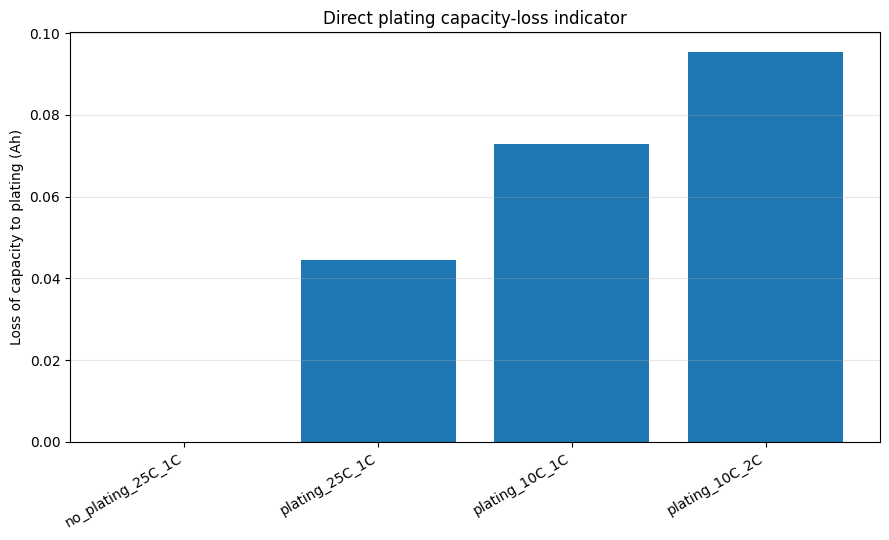

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_entry_capacity_loss_to_plating.png


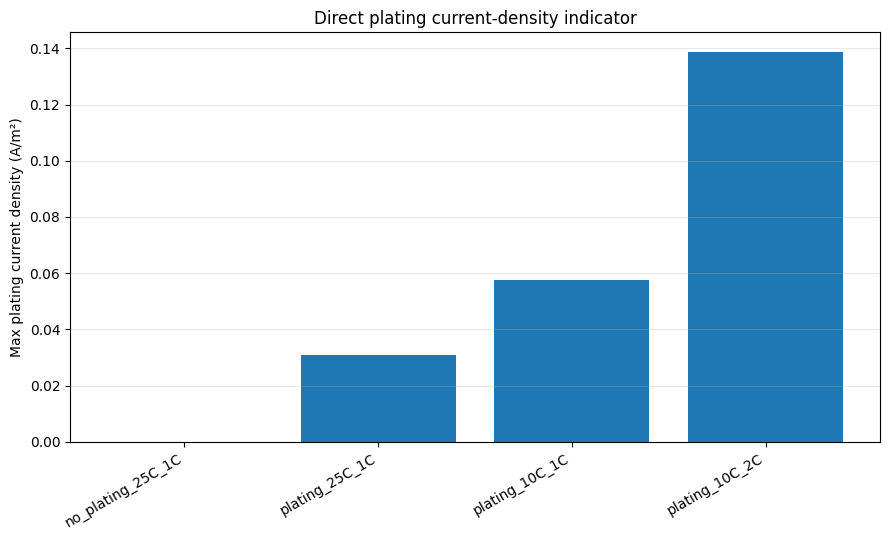

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_entry_current_density.png


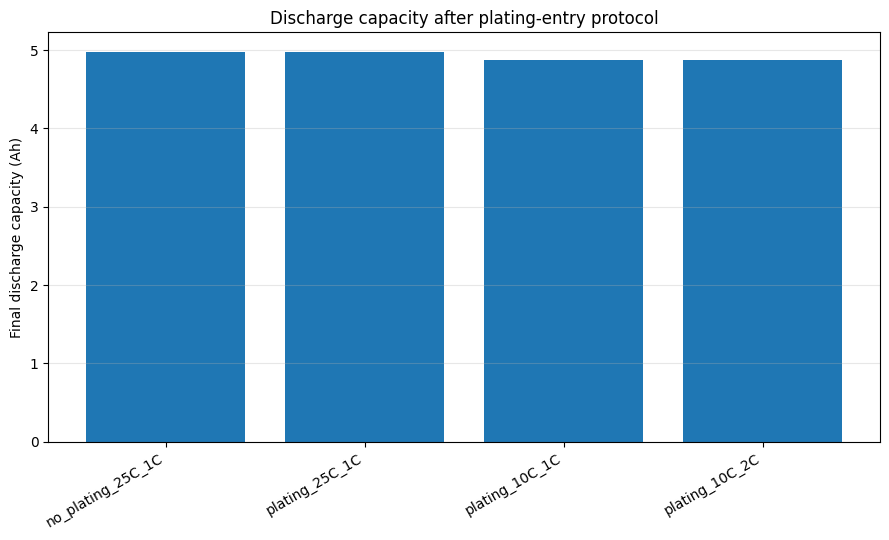

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_entry_discharge_capacity.png
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_classification_table.csv


,metric_layer,evidence,strength,classification
0,model_availability,OKane2022 plating model runs with SEI=solvent-...,strong,SEI-background plating model available
1,direct_plating_variables,Direct plating signal nonzero in 3/4 conditions.,strong,direct plating variables are observable
2,stress_sensitivity,Max plating current density = 0.138783 A/m²; m...,data-backed,plating response increases under lower tempera...
3,control_integrity,No-plating control direct signal nonzero = False.,strong,no-plating control is clean
4,overall,Plating entry audit completed with SEI-backgro...,supported,SEI-background plating branch is runnable and ...


In [14]:
# Cell 9 — Plating entry classification and figures（析锂入口分类与图像）

# Figure 1 — direct plating indicators
plt.figure(figsize=(9, 5.5))
plt.bar(
    plating_observability_compact["condition"],
    plating_observability_compact["loss_of_capacity_to_plating_Ah_abs_max"],
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Loss of capacity to plating (Ah)")
plt.title("Direct plating capacity-loss indicator")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
p = FIGURES / "plating_entry_capacity_loss_to_plating.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 2 — plating current density
plt.figure(figsize=(9, 5.5))
plt.bar(
    plating_observability_compact["condition"],
    plating_observability_compact["plating_current_density_A_m2_abs_max"],
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Max plating current density (A/m²)")
plt.title("Direct plating current-density indicator")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
p = FIGURES / "plating_entry_current_density.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Figure 3 — discharge capacity after charge/rest
plt.figure(figsize=(9, 5.5))
plt.bar(
    plating_capacity_table["condition"],
    plating_capacity_table["Q_discharge_Ah"],
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Final discharge capacity (Ah)")
plt.title("Discharge capacity after plating-entry protocol")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
p = FIGURES / "plating_entry_discharge_capacity.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

# Classification
direct_nonzero_count = int(
    plating_observability_table["any_direct_plating_signal_nonzero"].sum()
)

stress_max_current_density = float(
    plating_observability_table["plating_current_density_A_m2_abs_max"].max()
)

stress_max_capacity_to_plating = float(
    plating_observability_table["loss_of_capacity_to_plating_Ah_abs_max"].max()
)

no_plating_signal = bool(
    plating_observability_table.loc[
        plating_observability_table["condition"] == "no_plating_25C_1C",
        "any_direct_plating_signal_nonzero"
    ].iloc[0]
)

plating_enabled_signals = plating_observability_table[
    plating_observability_table["plating_mode"] != "none"
]["any_direct_plating_signal_nonzero"].all()

if (not no_plating_signal) and plating_enabled_signals:
    entry_strength = "supported"
    entry_classification = "SEI-background plating branch is runnable and directly observable"
else:
    entry_strength = "deferred"
    entry_classification = "plating observability requires protocol or model-option revision"

plating_entry_classification_table = pd.DataFrame([
    {
        "metric_layer": "model_availability",
        "evidence": "OKane2022 plating model runs with SEI=solvent-diffusion limited and partially reversible plating.",
        "strength": "strong",
        "classification": "SEI-background plating model available",
    },
    {
        "metric_layer": "direct_plating_variables",
        "evidence": (
            f"Direct plating signal nonzero in {direct_nonzero_count}/"
            f"{len(plating_observability_table)} conditions."
        ),
        "strength": "strong" if plating_enabled_signals else "limited",
        "classification": "direct plating variables are observable",
    },
    {
        "metric_layer": "stress_sensitivity",
        "evidence": (
            f"Max plating current density = {stress_max_current_density:.6g} A/m²; "
            f"max loss of capacity to plating = {stress_max_capacity_to_plating:.6g} Ah."
        ),
        "strength": "data-backed",
        "classification": "plating response increases under lower temperature / higher C-rate stress",
    },
    {
        "metric_layer": "control_integrity",
        "evidence": f"No-plating control direct signal nonzero = {no_plating_signal}.",
        "strength": "strong" if not no_plating_signal else "failed",
        "classification": "no-plating control is clean" if not no_plating_signal else "control contamination detected",
    },
    {
        "metric_layer": "overall",
        "evidence": "Plating entry audit completed with SEI-background model.",
        "strength": entry_strength,
        "classification": entry_classification,
    },
])

classification_path = DATA / "plating_entry_classification_table.csv"
plating_entry_classification_table.to_csv(classification_path, index=False)

print(f"[OK] saved: {classification_path}")
display(plating_entry_classification_table)

In [15]:
# Cell 10 — Notebook 25 output inventory audit（Notebook 25 输出文件清单审计）

expected_outputs = [
    DATA / "plating_entry_branch_contract.csv",
    DATA / "plating_entry_variable_inventory.csv",
    DATA / "plating_entry_protocol_table.csv",
    DATA / "plating_entry_observability_table.csv",
    DATA / "plating_entry_observability_compact.csv",
    DATA / "plating_entry_variable_source_audit.csv",
    DATA / "plating_entry_segment_audit.csv",
    DATA / "plating_entry_capacity_table.csv",
    DATA / "plating_entry_classification_table.csv",
    FIGURES / "plating_entry_capacity_loss_to_plating.png",
    FIGURES / "plating_entry_current_density.png",
    FIGURES / "plating_entry_discharge_capacity.png",
]

inventory_rows = []

for p in expected_outputs:
    inventory_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

output_inventory = pd.DataFrame(inventory_rows)

inventory_path = DATA / "plating_entry_output_inventory.csv"
output_inventory.to_csv(inventory_path, index=False)

print(f"[OK] saved: {inventory_path}")
display(output_inventory)

assert output_inventory["exists"].all(), "Some expected Notebook 25 outputs are missing."
print("[OK] All expected Notebook 25 outputs exist.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_output_inventory.csv


,path,exists,size_kB
0,data/plating_entry_branch_contract.csv,True,0.38
1,data/plating_entry_variable_inventory.csv,True,2.46
2,data/plating_entry_protocol_table.csv,True,0.81
3,data/plating_entry_observability_table.csv,True,6.81
4,data/plating_entry_observability_compact.csv,True,1.44
5,data/plating_entry_variable_source_audit.csv,True,0.72
6,data/plating_entry_segment_audit.csv,True,2.88
7,data/plating_entry_capacity_table.csv,True,1.10
8,data/plating_entry_classification_table.csv,True,0.75
9,figures/plating_entry_capacity_loss_to_plating...,True,111.94


[OK] All expected Notebook 25 outputs exist.


In [16]:
# Cell 11 — Matched no-plating control simulations
# （匹配无析锂对照仿真）

MATCHED_CONTROL_CONTRACT = pd.DataFrame([
    {
        "condition": "no_plating_10C_1C",
        "plating_mode": "none",
        "temperature_C": 10.0,
        "charge_rate": "1C",
        "initial_soc": 0.05,
        "role": "matched no-plating low-temperature 1C control",
    },
    {
        "condition": "no_plating_10C_2C",
        "plating_mode": "none",
        "temperature_C": 10.0,
        "charge_rate": "2C",
        "initial_soc": 0.05,
        "role": "matched no-plating low-temperature 2C control",
    },
])

matched_control_path = DATA / "plating_entry_matched_control_contract.csv"
MATCHED_CONTROL_CONTRACT.to_csv(matched_control_path, index=False)

print(f"[OK] saved: {matched_control_path}")
display(MATCHED_CONTROL_CONTRACT)

matched_control_solutions = {}

for _, row in MATCHED_CONTROL_CONTRACT.iterrows():
    matched_control_solutions[row["condition"]] = run_plating_entry_condition(row)

print("[OK] Matched no-plating controls solved.")
print("[N matched controls]", len(matched_control_solutions))

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_matched_control_contract.csv


,condition,plating_mode,temperature_C,charge_rate,initial_soc,role
0,no_plating_10C_1C,none,10.0,1C,0.05,matched no-plating low-temperature 1C control
1,no_plating_10C_2C,none,10.0,2C,0.05,matched no-plating low-temperature 2C control


[RUN] no_plating_10C_1C | plating=none | T=10.0 °C | charge=1C
[OK] solved: no_plating_10C_1C | runtime=1.5 s
[RUN] no_plating_10C_2C | plating=none | T=10.0 °C | charge=2C
[OK] solved: no_plating_10C_2C | runtime=1.6 s
[OK] Matched no-plating controls solved.
[N matched controls] 2


In [17]:
# Cell 12 — Matched control observability and capacity extraction
# （匹配对照的可观测性与容量提取）

# --- Observability extraction for matched controls ---

matched_obs_rows = []

for _, r in MATCHED_CONTROL_CONTRACT.iterrows():
    condition = r["condition"]
    sol = matched_control_solutions[condition]

    row = {
        "condition": condition,
        "plating_mode": r["plating_mode"],
        "temperature_C": float(r["temperature_C"]),
        "charge_rate": r["charge_rate"],
        "initial_soc": float(r["initial_soc"]),
        "role": r["role"],
    }

    row.update(extract_basic_protocol_observables(sol))

    for metric, candidates in PLATING_VARIABLE_CANDIDATES.items():
        out = get_variable_last_and_extrema(sol, candidates)

        row[f"{metric}_source"] = out["source"]
        row[f"{metric}_last"] = out["last"]
        row[f"{metric}_min"] = out["min"]
        row[f"{metric}_max"] = out["max"]
        row[f"{metric}_abs_max"] = out["abs_max"]
        row[f"{metric}_n_points"] = out["n_points"]

    matched_obs_rows.append(row)

matched_observability_table = pd.DataFrame(matched_obs_rows)

for col in DIRECT_SIGNAL_COLUMNS:
    if col not in matched_observability_table.columns:
        matched_observability_table[col] = np.nan

matched_observability_table["any_direct_plating_signal_nonzero"] = (
    matched_observability_table[DIRECT_SIGNAL_COLUMNS]
    .fillna(0.0)
    .abs()
    .max(axis=1)
    > 1e-14
)

matched_observability_table["capacity_loss_to_plating_nonzero"] = (
    matched_observability_table["loss_of_capacity_to_plating_Ah_abs_max"]
    .fillna(0.0)
    .abs()
    > 1e-12
)

matched_observability_table["plating_current_density_nonzero"] = (
    matched_observability_table["plating_current_density_A_m2_abs_max"]
    .fillna(0.0)
    .abs()
    > 1e-12
)

matched_obs_path = DATA / "plating_entry_matched_control_observability_table.csv"
matched_observability_table.to_csv(matched_obs_path, index=False)

print(f"[OK] saved: {matched_obs_path}")

display(
    matched_observability_table[
        [c for c in compact_cols if c in matched_observability_table.columns]
    ]
)

# --- Capacity extraction for matched controls ---

matched_segment_rows = []
matched_capacity_rows = []

for condition, sol in matched_control_solutions.items():
    seg = summarize_current_segments(sol, condition)
    matched_segment_rows.append(seg)

    discharge_candidates = seg[
        (seg["segment_type"] == "discharge")
        & (seg["I_mean_A"] > 1.0)
        & (seg["duration_min"] > 100)
    ].copy()

    if discharge_candidates.empty:
        raise RuntimeError(f"No valid final discharge segment found for {condition}")

    selected_discharge = discharge_candidates.sort_values("t_start_s").iloc[-1]

    cap = integrate_segment_capacity_Ah(
        sol=sol,
        idx_start=int(selected_discharge["idx_start"]),
        idx_stop=int(selected_discharge["idx_stop"]),
    )

    meta = MATCHED_CONTROL_CONTRACT[
        MATCHED_CONTROL_CONTRACT["condition"] == condition
    ].iloc[0].to_dict()

    matched_capacity_rows.append({
        "condition": condition,
        "plating_mode": meta["plating_mode"],
        "temperature_C": float(meta["temperature_C"]),
        "charge_rate": meta["charge_rate"],
        "selected_discharge_segment_id": int(selected_discharge["segment_id"]),
        **cap,
    })

matched_segment_audit = pd.concat(matched_segment_rows, ignore_index=True)
matched_capacity_table = pd.DataFrame(matched_capacity_rows)

matched_segment_path = DATA / "plating_entry_matched_control_segment_audit.csv"
matched_capacity_path = DATA / "plating_entry_matched_control_capacity_table.csv"

matched_segment_audit.to_csv(matched_segment_path, index=False)
matched_capacity_table.to_csv(matched_capacity_path, index=False)

print(f"[OK] saved: {matched_segment_path}")
print(f"[OK] saved: {matched_capacity_path}")

display(matched_capacity_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_matched_control_observability_table.csv


,condition,plating_mode,temperature_C,charge_rate,t_end_h,loss_of_capacity_to_plating_Ah_last,loss_of_capacity_to_plating_Ah_abs_max,loss_of_lithium_to_plating_mol_last,loss_of_lithium_to_plating_mol_abs_max,plated_lithium_concentration_abs_max,dead_lithium_concentration_abs_max,plated_lithium_thickness_m_abs_max,dead_lithium_thickness_m_abs_max,plating_current_density_A_m2_abs_max,plating_overpotential_V_abs_max,any_direct_plating_signal_nonzero,capacity_loss_to_plating_nonzero,plating_current_density_nonzero
0,no_plating_10C_1C,none,10.0,1C,7.004306,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False
1,no_plating_10C_2C,none,10.0,2C,6.871995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,False


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_matched_control_segment_audit.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_matched_control_capacity_table.csv


,condition,plating_mode,temperature_C,charge_rate,selected_discharge_segment_id,Q_signed_Ah,Q_charge_Ah,Q_discharge_Ah,U_start_V,U_end_V,I_mean_A,duration_min,n_points
0,no_plating_10C_1C,none,10.0,1C,2,4.880210,0.0,4.880210,4.051181,2.50001,1.666667,175.687552,1056
1,no_plating_10C_2C,none,10.0,2C,2,4.877728,0.0,4.877728,4.047273,2.50001,1.666667,175.598212,1055


In [20]:
# Cell 12A — Charge-segment audit for plating-entry protocol（析锂入口协议充电段审计）

all_segment_audit = pd.concat(
    [plating_segment_audit, matched_segment_audit],
    ignore_index=True,
    sort=False,
)

charge_segment_rows = []

for condition, seg in all_segment_audit.groupby("condition"):
    charge_candidates = seg[
        (seg["segment_type"] == "charge")
        & (seg["I_mean_A"] < -0.1)
    ].copy()

    if charge_candidates.empty:
        raise RuntimeError(f"No charge segment found for {condition}")

    charge = charge_candidates.sort_values("t_start_s").iloc[0]

    meta_source = pd.concat(
        [PLATING_CONTRACT, MATCHED_CONTROL_CONTRACT],
        ignore_index=True,
        sort=False,
    )

    meta = meta_source[meta_source["condition"] == condition].iloc[0].to_dict()

    charge_segment_rows.append({
        "condition": condition,
        "plating_mode": meta["plating_mode"],
        "temperature_C": float(meta["temperature_C"]),
        "stress_charge_rate": meta["charge_rate"],
        "charge_segment_id": int(charge["segment_id"]),
        "charge_duration_min": float(charge["duration_min"]),
        "charge_I_mean_A": float(charge["I_mean_A"]),
        "charge_I_min_A": float(charge["I_min_A"]),
        "charge_I_max_A": float(charge["I_max_A"]),
        "charge_U_start_V": float(charge["U_start_V"]),
        "charge_U_end_V": float(charge["U_end_V"]),
        "n_points": int(charge["n_points"]),
    })

plating_entry_charge_segment_audit = pd.DataFrame(charge_segment_rows)

charge_audit_path = DATA / "plating_entry_charge_segment_audit.csv"
plating_entry_charge_segment_audit.to_csv(charge_audit_path, index=False)

print(f"[OK] saved: {charge_audit_path}")
display(plating_entry_charge_segment_audit.sort_values(["temperature_C", "stress_charge_rate", "plating_mode"]))

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_charge_segment_audit.csv


,condition,plating_mode,temperature_C,stress_charge_rate,charge_segment_id,charge_duration_min,charge_I_mean_A,charge_I_min_A,charge_I_max_A,charge_U_start_V,charge_U_end_V,n_points
0,no_plating_10C_1C,none,10.0,1C,0,124.570834,-2.281277,-5.000483,-0.25005,3.332367,4.2,751
3,plating_10C_1C,partially reversible,10.0,1C,0,123.584298,-2.296465,-5.000493,-0.25005,3.332367,4.2,744
1,no_plating_10C_2C,none,10.0,2C,0,116.721464,-2.440555,-10.000661,-0.25005,3.422853,4.2,703
4,plating_10C_2C,partially reversible,10.0,2C,0,115.302663,-2.467159,-10.000664,-0.25005,3.422853,4.2,695
2,no_plating_25C_1C,none,25.0,1C,0,97.424448,-2.948036,-5.000539,-0.25005,3.287859,4.2,588
5,plating_25C_1C,partially reversible,25.0,1C,0,97.076481,-2.958354,-5.000546,-0.25005,3.287859,4.2,586


In [18]:
# Cell 13 — Matched plating-effect audit
# （匹配条件下的析锂效应审计）

# Combine original and matched observability/capacity tables
all_entry_observability = pd.concat(
    [plating_observability_table, matched_observability_table],
    ignore_index=True,
    sort=False,
)

all_entry_capacity = pd.concat(
    [plating_capacity_table, matched_capacity_table],
    ignore_index=True,
    sort=False,
)

# Pairing map
MATCHED_PAIRS = [
    {
        "pair": "25C_1C",
        "control": "no_plating_25C_1C",
        "plating": "plating_25C_1C",
    },
    {
        "pair": "10C_1C",
        "control": "no_plating_10C_1C",
        "plating": "plating_10C_1C",
    },
    {
        "pair": "10C_2C",
        "control": "no_plating_10C_2C",
        "plating": "plating_10C_2C",
    },
]

matched_effect_rows = []

for pair in MATCHED_PAIRS:
    control = pair["control"]
    plating = pair["plating"]

    c_obs = all_entry_observability[all_entry_observability["condition"] == control].iloc[0]
    p_obs = all_entry_observability[all_entry_observability["condition"] == plating].iloc[0]

    c_cap = all_entry_capacity[all_entry_capacity["condition"] == control].iloc[0]
    p_cap = all_entry_capacity[all_entry_capacity["condition"] == plating].iloc[0]

    delta_discharge_capacity_Ah = float(p_cap["Q_discharge_Ah"] - c_cap["Q_discharge_Ah"])
    delta_discharge_capacity_pct = (
        delta_discharge_capacity_Ah / float(c_cap["Q_discharge_Ah"]) * 100
    )

    matched_effect_rows.append({
        "pair": pair["pair"],
        "control_condition": control,
        "plating_condition": plating,
        "temperature_C": float(p_obs["temperature_C"]),
        "charge_rate": p_obs["charge_rate"],

        "control_direct_plating_signal": bool(c_obs["any_direct_plating_signal_nonzero"]),
        "plating_direct_plating_signal": bool(p_obs["any_direct_plating_signal_nonzero"]),

        "plating_loss_capacity_Ah_abs_max": float(p_obs["loss_of_capacity_to_plating_Ah_abs_max"]),
        "plating_loss_lithium_mol_abs_max": float(p_obs["loss_of_lithium_to_plating_mol_abs_max"]),
        "plating_current_density_A_m2_abs_max": float(p_obs["plating_current_density_A_m2_abs_max"]),
        "plated_lithium_thickness_m_abs_max": float(p_obs["plated_lithium_thickness_m_abs_max"]),
        "dead_lithium_thickness_m_abs_max": float(p_obs["dead_lithium_thickness_m_abs_max"]),

        "control_Q_discharge_Ah": float(c_cap["Q_discharge_Ah"]),
        "plating_Q_discharge_Ah": float(p_cap["Q_discharge_Ah"]),
        "delta_Q_discharge_plating_minus_control_Ah": delta_discharge_capacity_Ah,
        "delta_Q_discharge_plating_minus_control_pct": delta_discharge_capacity_pct,
    })

matched_plating_effect_audit = pd.DataFrame(matched_effect_rows)

matched_effect_path = DATA / "plating_entry_matched_plating_effect_audit.csv"
matched_plating_effect_audit.to_csv(matched_effect_path, index=False)

print(f"[OK] saved: {matched_effect_path}")
display(matched_plating_effect_audit)

# Revised classification using matched controls
all_controls_clean = not matched_plating_effect_audit["control_direct_plating_signal"].any()
all_plating_detected = matched_plating_effect_audit["plating_direct_plating_signal"].all()

max_direct_plating_capacity_Ah = float(
    matched_plating_effect_audit["plating_loss_capacity_Ah_abs_max"].max()
)

max_delta_discharge_Ah = float(
    matched_plating_effect_audit["delta_Q_discharge_plating_minus_control_Ah"].abs().max()
)

if all_controls_clean and all_plating_detected:
    revised_strength = "supported"
    revised_classification = "matched-control plating entry is directly observable"
else:
    revised_strength = "deferred"
    revised_classification = "matched-control plating entry requires revision"

plating_entry_revised_classification_table = pd.DataFrame([
    {
        "metric_layer": "matched_controls",
        "evidence": f"All matched no-plating controls clean = {all_controls_clean}.",
        "strength": "strong" if all_controls_clean else "failed",
        "classification": "matched no-plating controls are clean",
    },
    {
        "metric_layer": "direct_plating_variables",
        "evidence": f"All plating-enabled matched cases show direct plating signal = {all_plating_detected}.",
        "strength": "strong" if all_plating_detected else "limited",
        "classification": "direct plating variables are observable under matched stress conditions",
    },
    {
        "metric_layer": "plating_stress_sensitivity",
        "evidence": (
            f"Max direct loss of capacity to plating = {max_direct_plating_capacity_Ah:.6f} Ah."
        ),
        "strength": "data-backed",
        "classification": "plating signal increases under low-temperature and high-rate stress",
    },
    {
        "metric_layer": "capacity_after_protocol",
        "evidence": (
            f"Max matched discharge-capacity difference = {max_delta_discharge_Ah:.6f} Ah."
        ),
        "strength": "audit-level",
        "classification": "post-protocol capacity effect must be interpreted with matched controls",
    },
    {
        "metric_layer": "overall",
        "evidence": "SEI-background plating entry audit completed with matched no-plating controls.",
        "strength": revised_strength,
        "classification": revised_classification,
    },
])

revised_class_path = DATA / "plating_entry_revised_classification_table.csv"
plating_entry_revised_classification_table.to_csv(revised_class_path, index=False)

print(f"[OK] saved: {revised_class_path}")
display(plating_entry_revised_classification_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_matched_plating_effect_audit.csv


,pair,control_condition,plating_condition,temperature_C,charge_rate,control_direct_plating_signal,plating_direct_plating_signal,plating_loss_capacity_Ah_abs_max,plating_loss_lithium_mol_abs_max,plating_current_density_A_m2_abs_max,plated_lithium_thickness_m_abs_max,dead_lithium_thickness_m_abs_max,control_Q_discharge_Ah,plating_Q_discharge_Ah,delta_Q_discharge_plating_minus_control_Ah,delta_Q_discharge_plating_minus_control_pct
0,25C_1C,no_plating_25C_1C,plating_25C_1C,25.0,1C,False,True,0.044523,0.001661,0.030974,6.417975e-09,2.713942e-11,4.978101,4.975338,-0.002763,-0.055500
1,10C_1C,no_plating_10C_1C,plating_10C_1C,10.0,1C,False,True,0.072795,0.002716,0.057522,1.048452e-08,5.566762e-11,4.880210,4.872680,-0.007530,-0.154287
2,10C_2C,no_plating_10C_2C,plating_10C_2C,10.0,2C,False,True,0.095446,0.003561,0.138783,1.376115e-08,7.485025e-11,4.877728,4.867616,-0.010112,-0.207307


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_revised_classification_table.csv


,metric_layer,evidence,strength,classification
0,matched_controls,All matched no-plating controls clean = True.,strong,matched no-plating controls are clean
1,direct_plating_variables,All plating-enabled matched cases show direct ...,strong,direct plating variables are observable under ...
2,plating_stress_sensitivity,Max direct loss of capacity to plating = 0.095...,data-backed,plating signal increases under low-temperature...
3,capacity_after_protocol,Max matched discharge-capacity difference = 0....,audit-level,post-protocol capacity effect must be interpre...
4,overall,SEI-background plating entry audit completed w...,supported,matched-control plating entry is directly obse...


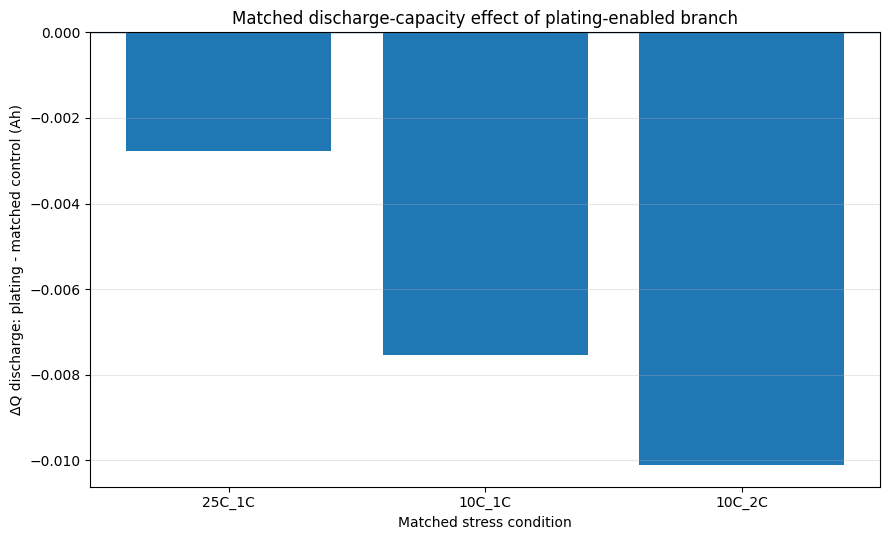

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_entry_matched_capacity_difference.png


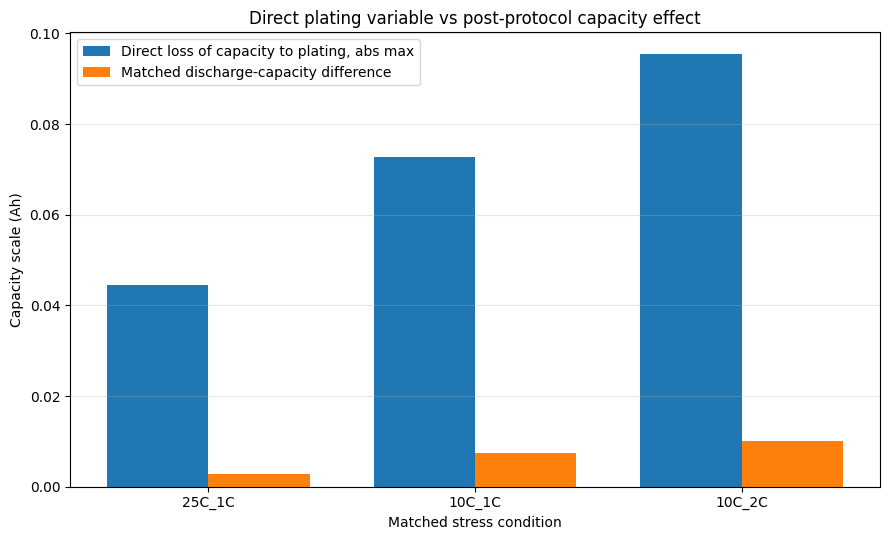

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_entry_direct_vs_matched_capacity_effect.png


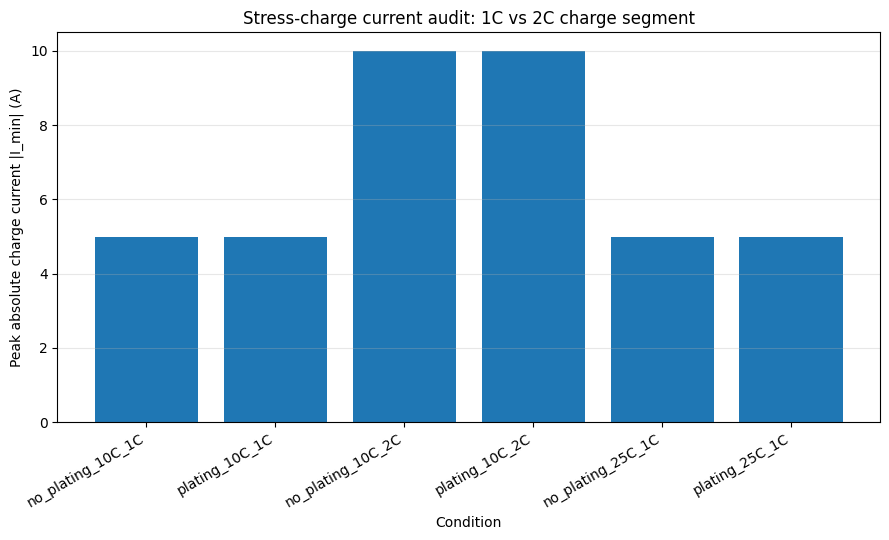

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/plating_entry_charge_segment_current_audit.png


In [22]:
# Cell 13A — Matched-control and charge-segment visualization
# （匹配对照与充电段审计可视化）

# Figure 4 — Matched plating vs no-plating discharge-capacity difference
plt.figure(figsize=(9, 5.5))

plt.bar(
    matched_plating_effect_audit["pair"],
    matched_plating_effect_audit["delta_Q_discharge_plating_minus_control_Ah"],
)

plt.axhline(0, linewidth=1)
plt.ylabel("ΔQ discharge: plating - matched control (Ah)")
plt.xlabel("Matched stress condition")
plt.title("Matched discharge-capacity effect of plating-enabled branch")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

p = FIGURES / "plating_entry_matched_capacity_difference.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")


# Figure 5 — Direct plating capacity-loss indicator vs matched discharge-capacity effect
plt.figure(figsize=(9, 5.5))

x = np.arange(len(matched_plating_effect_audit))
width = 0.38

plt.bar(
    x - width / 2,
    matched_plating_effect_audit["plating_loss_capacity_Ah_abs_max"],
    width=width,
    label="Direct loss of capacity to plating, abs max",
)

plt.bar(
    x + width / 2,
    np.abs(matched_plating_effect_audit["delta_Q_discharge_plating_minus_control_Ah"]),
    width=width,
    label="Matched discharge-capacity difference",
)

plt.xticks(x, matched_plating_effect_audit["pair"])
plt.ylabel("Capacity scale (Ah)")
plt.xlabel("Matched stress condition")
plt.title("Direct plating variable vs post-protocol capacity effect")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

p = FIGURES / "plating_entry_direct_vs_matched_capacity_effect.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")


# Figure 6 — Charge-segment stress current audit
plt.figure(figsize=(9, 5.5))

plot_df = plating_entry_charge_segment_audit.copy()
plot_df = plot_df.sort_values(["temperature_C", "stress_charge_rate", "plating_mode"])

plt.bar(
    plot_df["condition"],
    np.abs(plot_df["charge_I_min_A"]),
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Peak absolute charge current |I_min| (A)")
plt.xlabel("Condition")
plt.title("Stress-charge current audit: 1C vs 2C charge segment")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

p = FIGURES / "plating_entry_charge_segment_current_audit.png"
plt.savefig(p, dpi=300)
plt.show()
print(f"[OK] saved: {p}")

In [23]:
# Cell 14 — Revised Notebook 25 output inventory audit
# （修正后的 Notebook 25 输出文件清单审计）

expected_outputs_revised = [
    DATA / "plating_entry_branch_contract.csv",
    DATA / "plating_entry_variable_inventory.csv",
    DATA / "plating_entry_protocol_table.csv",
    DATA / "plating_entry_observability_table.csv",
    DATA / "plating_entry_observability_compact.csv",
    DATA / "plating_entry_variable_source_audit.csv",
    DATA / "plating_entry_segment_audit.csv",
    DATA / "plating_entry_capacity_table.csv",
    DATA / "plating_entry_classification_table.csv",
    DATA / "plating_entry_charge_segment_audit.csv",

    DATA / "plating_entry_matched_control_contract.csv",
    DATA / "plating_entry_matched_control_observability_table.csv",
    DATA / "plating_entry_matched_control_segment_audit.csv",
    DATA / "plating_entry_matched_control_capacity_table.csv",
    DATA / "plating_entry_matched_plating_effect_audit.csv",
    DATA / "plating_entry_revised_classification_table.csv",

    FIGURES / "plating_entry_capacity_loss_to_plating.png",
    FIGURES / "plating_entry_current_density.png",
    FIGURES / "plating_entry_discharge_capacity.png",
    FIGURES / "plating_entry_matched_capacity_difference.png",
    FIGURES / "plating_entry_direct_vs_matched_capacity_effect.png",
    FIGURES / "plating_entry_charge_segment_current_audit.png",
]

inventory_rows = []

for p in expected_outputs_revised:
    inventory_rows.append({
        "path": str(p.relative_to(REPO)),
        "exists": p.exists(),
        "size_kB": round(p.stat().st_size / 1024, 2) if p.exists() else np.nan,
    })

output_inventory_revised = pd.DataFrame(inventory_rows)

inventory_revised_path = DATA / "plating_entry_output_inventory_revised.csv"
output_inventory_revised.to_csv(inventory_revised_path, index=False)

print(f"[OK] saved: {inventory_revised_path}")
display(output_inventory_revised)

assert output_inventory_revised["exists"].all(), "Some expected revised Notebook 25 outputs are missing."
print("[OK] All expected revised Notebook 25 outputs exist.")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/plating_entry_output_inventory_revised.csv


,path,exists,size_kB
0,data/plating_entry_branch_contract.csv,True,0.38
1,data/plating_entry_variable_inventory.csv,True,2.46
2,data/plating_entry_protocol_table.csv,True,0.81
3,data/plating_entry_observability_table.csv,True,6.81
4,data/plating_entry_observability_compact.csv,True,1.44
5,data/plating_entry_variable_source_audit.csv,True,0.72
6,data/plating_entry_segment_audit.csv,True,2.88
7,data/plating_entry_capacity_table.csv,True,1.10
8,data/plating_entry_classification_table.csv,True,0.75
9,data/plating_entry_charge_segment_audit.csv,True,1.07


[OK] All expected revised Notebook 25 outputs exist.


## Final closure — Notebook 25

### Key findings

Notebook 25 audited the entry-level observability of lithium plating（析锂）within the PyBaMM aging-bridge workflow.

This notebook did not attempt to establish a full plating fingerprint. Instead, it tested whether an SEI-background plating model can be run, whether direct plating variables are accessible, and whether plating-enabled branches can be separated from matched no-plating controls.

The model had to be revised after the first attempt. OKane2022 partially reversible lithium plating（部分可逆析锂）depends on SEI thickness（SEI 厚度） through the dead-lithium decay relation. Therefore, `SEI = none` produced a division-by-zero failure. The corrected model uses:

- SEI = solvent-diffusion limited,
- lithium plating = partially reversible,
- lithium plating porosity change = false,
- LAM disabled,
- particle mechanics disabled,
- isothermal model.

This means Notebook 25 is an **SEI-background plating entry audit（SEI 背景下的析锂入口审计）**, not a pure plating-without-SEI branch.

### Protocol design

The entry protocol starts from low SOC:

- initial SOC = 0.05,
- charge to 4.2 V at the specified stress charge rate,
- hold at 4.2 V until C/20,
- rest for 60 min,
- discharge at C/3 to 2.5 V,
- rest for 60 min.

Audited stress conditions:

- no_plating_25C_1C,
- plating_25C_1C,
- plating_10C_1C,
- plating_10C_2C.

Additional matched no-plating controls were added:

- no_plating_10C_1C,
- no_plating_10C_2C.

### Charge-segment audit

A charge-segment audit was added to avoid confusion between the stress-charge rate and the final discharge rate.

The stress-charge segment confirmed the intended charge currents:

- 1C cases reached approximately −5 A during charge,
- 2C cases reached approximately −10 A during charge.

The final discharge segment uses a fixed C/3 rate, so its mean current is approximately +1.6667 A in all cases.

Therefore:

- `stress_charge_rate` refers to the preceding charge stress,
- the final capacity table reports C/3 discharge capacity after that stress protocol.

The original `charge_rate` naming is potentially misleading and should be interpreted as `stress_charge_rate`.

### Direct plating observability

Direct negative-electrode plating variables were available and extractable, including:

- loss of capacity to negative lithium plating,
- loss of lithium to negative lithium plating,
- negative lithium plating concentration,
- negative dead lithium concentration,
- negative lithium plating thickness,
- negative dead lithium thickness,
- negative electrode lithium plating interfacial current density,
- negative electrode lithium plating reaction overpotential.

The no-plating control was clean:

- no_plating_25C_1C: direct plating signal = False,
- no_plating_10C_1C: direct plating signal = False,
- no_plating_10C_2C: direct plating signal = False.

All plating-enabled cases showed direct plating signals:

- plating_25C_1C: direct plating signal = True,
- plating_10C_1C: direct plating signal = True,
- plating_10C_2C: direct plating signal = True.

The direct plating indicators increased under stronger stress:

Loss of capacity to plating, peak / absolute maximum:

- plating_25C_1C: ≈ 0.0445 Ah,
- plating_10C_1C: ≈ 0.0728 Ah,
- plating_10C_2C: ≈ 0.0954 Ah.

Maximum plating current density:

- plating_25C_1C: ≈ 0.031 A/m²,
- plating_10C_1C: ≈ 0.058 A/m²,
- plating_10C_2C: ≈ 0.139 A/m².

This supports the entry-level conclusion that SEI-background lithium plating is directly observable and stress-sensitive.

### Matched-control capacity audit

Matched no-plating controls were required because temperature and charge rate also affect the final discharge capacity.

The matched pairs were:

- plating_25C_1C vs no_plating_25C_1C,
- plating_10C_1C vs no_plating_10C_1C,
- plating_10C_2C vs no_plating_10C_2C.

The matched discharge-capacity differences were:

- 25C_1C: −0.002763 Ah, approximately −0.0555%,
- 10C_1C: −0.007530 Ah, approximately −0.1543%,
- 10C_2C: −0.010112 Ah, approximately −0.2073%.

These matched capacity differences are much smaller than the peak loss-of-capacity-to-plating variables.

This is physically plausible because the selected plating mode is partially reversible. Some plated lithium can be stripped or recovered during the subsequent protocol, so the maximum plating variable should not be interpreted as direct irreversible capacity loss.

### Interpretation boundary

The direct plating variables prove that plating is activated and observable in the model.

However:

- direct plating abs_max is not equal to final irreversible capacity loss;
- post-protocol capacity difference must be interpreted using matched no-plating controls;
- voltage changes alone are not accepted as plating evidence;
- this notebook does not yet establish a full plating fingerprint.

The entry-level plating audit is therefore supported, but the full mechanism-fingerprint branch remains deferred.

### Correct conclusion wording

Supported:

- OKane2022 partially reversible plating runs when SEI background is enabled.
- Direct negative-electrode plating variables are available and extractable.
- Matched no-plating controls are clean.
- Plating-enabled matched cases show direct plating signals.
- Plating indicators increase under lower temperature and higher charge rate.
- Post-stress discharge capacity differences are measurable under matched controls.

Not supported:

- This notebook does not establish a full plating fingerprint.
- Direct loss-of-capacity-to-plating peak values should not be interpreted as final irreversible capacity loss.
- Voltage trajectory alone is not sufficient to identify plating.
- Capacity loss relative to a non-matched 25°C control is not a clean plating-specific metric.
- HPPC Ri(t), corrected relaxation, C/25 V(Q), GITT-like finite-rest voltage, and ICA/DVA under plating were not audited here.

### Project-level classification

`plating entry observability = supported`

`full plating fingerprint = deferred`

Project-level wording:

> SEI-background partially reversible lithium plating is runnable and directly observable in OKane2022. Matched no-plating controls are clean, and plating-enabled conditions show stress-sensitive direct plating variables. However, post-protocol capacity changes are much smaller than peak plating variables and must be interpreted with matched controls. A full plating fingerprint requires a separate follow-up audit.

### Porsche-oriented interpretation

Notebook 25 supports the Porsche-oriented aging-modeling workflow by demonstrating how to separate direct mechanism variables from protocol-level observables.

It shows that plating analysis requires matched controls and cannot rely only on final capacity or voltage behavior. This is directly relevant for measurement-based aging-model validation, where low-temperature fast-charge effects must be separated from generic temperature and voltage-boundary effects.

### Next step

The next notebook should be:

`26_plating_full_fingerprint_audit.ipynb`

It should use the supported plating-entry protocols and extend the audit to:

1. HPPC Ri(t)（时间窗内阻）,
2. corrected relaxation descriptors（修正后恢复描述符）,
3. C/25 OCV-like V(Q)（C/25 近似 OCV 电压曲线）,
4. GITT-like finite-rest voltage（GITT-like 有限静置电压）,
5. ICA/DVA central features（中央窗口微分电压特征）,
6. Mechanism Fingerprint Registry v0.2 output.

Only after that should plating be included in a cross-mechanism synthesis table.

### Additional visualization audit

After the matched-control audit, three additional figures were added to make the protocol logic explicit:

- `plating_entry_matched_capacity_difference.png` shows the matched discharge-capacity difference between plating-enabled and no-plating branches.
- `plating_entry_direct_vs_matched_capacity_effect.png` compares direct plating-variable magnitude with post-protocol discharge-capacity effect, showing that peak plating variables must not be interpreted as final irreversible capacity loss.
- `plating_entry_charge_segment_current_audit.png` confirms that 1C / 2C stress differences occur in the charge segment, while the final discharge capacity check is performed at a common C/3 rate.